# Model interpretation: XGBoost feature importance, SHAP, dependence

What is tested: interpretation of the baseline per-generator XGBoost
models (train 2015-2021, train_tail stop, val 2022 — identical to
`notebooks/xgboost_baseline.ipynb`), in three views:

1. **Gain importance**: xgboost's built-in per-split gain importance,
    normalized per generator, top features by mean across generators.
2. **SHAP**: mean absolute treeSHAP value per feature on val 2022
    (via `pred_contribs`, no extra package), normalized per generator;
    the ranking is compared against the gain ranking.
3. **Dependence**: predicted vs actual ON-rate by 20 quantile bins of
    the local price-minus-water-value feature, and by hour of day, for
    three representative generators (Tokke_G1, Vinje_G1, Lio_G1).

The fit cell prints the per-generator AUC and micro AUC as a
reproduction check against the baseline (0.9802).

In [1]:
import gc

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
import yaml
from sklearn.metrics import roc_auc_score

HOURS = 168

In [2]:
DATA = "../data/kernel"
EXT = "../data/extended"

price = pd.read_csv(f"{DATA}/Historical_day_ahead_price_2015_2025.csv")
inflow = pd.read_csv(f"{DATA}/Historical_inflow_1958_2025.csv")
volume = pd.read_csv(f"{DATA}/Historical_volume_2015_2024.csv")
water = pd.read_csv(f"{DATA}/Synthetic_water_value_2015_2024.csv")
target = pd.read_csv(f"{DATA}/Unit_commitment_decisions.csv")
min_flow = pd.read_csv(f"{EXT}/Constraint_min_flow.csv")
min_volume = pd.read_csv(f"{EXT}/Constraint_min_volume.csv")
topology = yaml.safe_load(open(f"{EXT}/Tokke_Vinje_topology.yaml"))


def indexed(df):
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"], utc=True, format="mixed")
    return df.sort_values("date").set_index("date")


price_h = indexed(price)["Day-ahead price (EUR/MWh)"].resample("1h").mean()
inf_wide = indexed(inflow)
vol_wide = indexed(volume)
wv_wide = indexed(water)
mf_wide = indexed(min_flow)
mv_wide = indexed(min_volume)

RESERVOIRS = list(vol_wide.columns)
CAPACITY = {r: float(topology["model"]["reservoir"][r]["max_vol"]) for r in RESERVOIRS}

target["starttime"] = pd.to_datetime(target["starttime"], utc=True, format="mixed")
target = target.sort_values("starttime").reset_index(drop=True)

GENERATORS = sorted(
    {c.removeprefix("result_committed_").rsplit("_t", 1)[0]
     for c in target.columns if c.startswith("result_committed")}
)

connections = topology["connections"]


def supplying_reservoirs(name, kind):
    if kind == "reservoir":
        return {name}
    out = set()
    for e in connections:
        if e["to"] == name and e["to_type"] == kind and e["from_type"] in {"reservoir", "tunnel"}:
            out |= supplying_reservoirs(e["from"], e["from_type"])
    return out


FEEDERS = {}
for gen in GENERATORS:
    plant = next(e["to"] for e in connections
                 if e["from"] == gen and e["from_type"] == "generator" and e["to_type"] == "plant")
    FEEDERS[gen] = sorted(supplying_reservoirs(plant, "plant"))

print("cases:", len(target), " generators:", len(GENERATORS))

cases: 2922  generators: 14


## Feature engineering and split

What is tested: the unchanged 193-column feature set and the baseline
split (train starts < 2022-01-01, stop on the last 90 days of train,
val = full 2022), copied verbatim from
`notebooks/xgboost_baseline.ipynb`.

In [3]:
def lookup(frame, timestamps, columns=None):
    f = frame if columns is None else frame[columns]
    return f.reindex(pd.DatetimeIndex(timestamps)).to_numpy(dtype=np.float32)


def feature_matrix(cases):
    starts = pd.DatetimeIndex(cases["starttime"])
    n = len(starts)
    ts = pd.DatetimeIndex(np.repeat(starts.to_numpy(), HOURS)) + pd.to_timedelta(
        np.tile(np.arange(HOURS), n), unit="h"
    )
    price = lookup(price_h, ts).reshape(n, HOURS)
    initial = lookup(vol_wide, starts, RESERVOIRS)
    terminal = lookup(wv_wide, starts + pd.Timedelta(hours=HOURS), RESERVOIRS)
    inflow = lookup(inf_wide, ts).reshape(n, HOURS, -1)
    minflow = lookup(mf_wide, ts).reshape(n, HOURS, -1)
    minvol = lookup(mv_wide, ts).reshape(n, HOURS, -1)

    F = {}

    def add(name, v):
        v = np.asarray(v, dtype=np.float32)
        if v.shape == (n,):
            v = np.repeat(v, HOURS)
        elif v.shape == (n, HOURS):
            v = v.reshape(-1)
        F[name] = v

    h = np.tile(np.arange(HOURS, dtype=np.float32), n)
    add("horizon_hour", h)
    add("hours_remaining", HOURS - 1 - h)
    add("hour_of_day", ts.hour.to_numpy())
    add("day_of_week", ts.dayofweek.to_numpy())
    add("month", ts.month.to_numpy())
    add("doy_sin", np.sin(2 * np.pi * ts.dayofyear.to_numpy() / 365.25))
    add("doy_cos", np.cos(2 * np.pi * ts.dayofyear.to_numpy() / 365.25))

    add("price", price)
    for stat, v in (("mean", price.mean(1)), ("std", price.std(1)),
                    ("min", price.min(1)), ("max", price.max(1))):
        add(f"price_week_{stat}", v)
    add("price_minus_week_mean", price - price.mean(1, keepdims=True))
    add("price_week_rank", pd.DataFrame(price).rank(axis=1, pct=True).to_numpy())
    daily = price.reshape(n, 7, 24)
    for stat, v in (("mean", daily.mean(2)), ("min", daily.min(2)), ("max", daily.max(2))):
        add(f"price_day_{stat}", np.repeat(v, 24, axis=1))
    add("price_prefix_mean", price.cumsum(1) / np.arange(1, HOURS + 1))
    add("price_suffix_mean", price[:, ::-1].cumsum(1)[:, ::-1] / np.arange(HOURS, 0, -1))
    for off in (-24, -6, -1, 1, 6, 24):
        add(f"price_offset_{off:+d}", price[:, np.clip(np.arange(HOURS) + off, 0, HOURS - 1)])

    for j, res in enumerate(RESERVOIRS):
        add(f"init_vol__{res}", initial[:, j])
        add(f"init_frac__{res}", initial[:, j] / CAPACITY[res])
        add(f"term_val__{res}", terminal[:, j])
        add(f"price_minus_val__{res}", price - terminal[:, j, None])

    for j, name in enumerate(inf_wide.columns):
        flow = inflow[:, :, j]
        cum = flow.cumsum(1) * (3600 / 1e6)
        add(f"inflow__{name}", flow)
        add(f"inflow_week_mean__{name}", flow.mean(1))
        add(f"inflow_cum_Mm3__{name}", cum)
        add(f"inflow_rem_Mm3__{name}", cum[:, -1:] - cum)

    for j, name in enumerate(mf_wide.columns):
        add(f"minflow__{name}", minflow[:, :, j])
        add(f"minflow_week_max__{name}", minflow[:, :, j].max(1))
    for j, name in enumerate(mv_wide.columns):
        add(f"minvol__{name}", minvol[:, :, j])
        add(f"minvol_week_max__{name}", minvol[:, :, j].max(1))
        add(f"init_margin_to_minvol__{name}", initial[:, RESERVOIRS.index(name), None] - minvol[:, :, j])

    return pd.DataFrame(F, dtype=np.float32)


def generator_features(base, gen):
    X = base.copy()
    feeders = FEEDERS[gen]
    capacity = sum(CAPACITY[r] for r in feeders)
    total_init = sum(base[f"init_vol__{r}"] for r in feeders)
    value = sum(base[f"term_val__{r}"] * CAPACITY[r] for r in feeders) / capacity
    cum = sum(base[f"inflow_cum_Mm3__{r}"] for r in feeders)
    rem = sum(base[f"inflow_rem_Mm3__{r}"] for r in feeders)

    X["local_init_frac"] = total_init / capacity
    X["local_term_val"] = value
    X["local_price_minus_val"] = base["price"] - value
    X["local_inflow"] = sum(base[f"inflow__{r}"] for r in feeders)
    X["local_cum_frac"] = cum / capacity
    X["local_rem_frac"] = rem / capacity
    X["local_available_frac"] = (total_init + cum + rem) / capacity
    return X


def labels_for(cases, gen):
    cols = [f"result_committed_{gen}_t{t}" for t in range(HOURS)]
    return cases[cols].to_numpy(dtype=np.uint8).reshape(-1)


split = pd.Timestamp("2022-01-01", tz="UTC")
train_cases = target[target["starttime"] < split].reset_index(drop=True)
val_cases = target[target["starttime"] >= split].reset_index(drop=True)
stop_cases = train_cases[
    train_cases["starttime"] >= split - pd.Timedelta(days=90)
].reset_index(drop=True)
print("train cases:", len(train_cases), " stop cases:", len(stop_cases),
      " val cases:", len(val_cases))

Xtr_base = feature_matrix(train_cases)
Xst_base = feature_matrix(stop_cases)
Xva_base = feature_matrix(val_cases)
print("feature matrix:", Xtr_base.shape)

train cases: 2557  stop cases: 90  val cases: 365
feature matrix: (429576, 186)


## Fit the baseline models

What is tested: the 14 per-generator XGBoost models under the baseline
protocol, kept in memory for the interpretation steps. Printed:
per-generator AUC and micro AUC (reproduction check against 0.9802).

In [4]:
models, preds = {}, {}
rows = []
for gen in GENERATORS:
    Xtr = generator_features(Xtr_base, gen)
    Xst = generator_features(Xst_base, gen)
    Xva = generator_features(Xva_base, gen)
    ytr = labels_for(train_cases, gen)
    yst = labels_for(stop_cases, gen)
    yva = labels_for(val_cases, gen)

    if np.unique(ytr).size == 1:
        models[gen] = None
        preds[gen] = np.full(len(yva), float(ytr[0]), dtype=np.float32)
        rows.append({"generator": gen, "AUC": None})
    else:
        clf = xgb.XGBClassifier(
            n_estimators=400, learning_rate=0.05, max_depth=7,
            subsample=0.8, colsample_bytree=0.8, tree_method="hist",
            eval_metric="auc", early_stopping_rounds=25, random_state=0,
        )
        clf.fit(Xtr, ytr, eval_set=[(Xst, yst)], verbose=False)
        models[gen] = clf
        preds[gen] = clf.predict_proba(Xva)[:, 1].astype(np.float32)
        rows.append({"generator": gen, "AUC": roc_auc_score(yva, preds[gen])})
        print(f"{gen:16s} AUC {rows[-1]['AUC']:.4f}")
    del Xtr, Xst, Xva
    gc.collect()

y_all = np.concatenate([labels_for(val_cases, g) for g in GENERATORS])
p_all = np.concatenate([preds[g] for g in GENERATORS])
print("micro AUC:", round(roc_auc_score(y_all, p_all), 4))
pd.DataFrame(rows).set_index("generator").round(4)

Byrte_G1         AUC 0.9951
Haukeli_G1       AUC 0.9352
Hogga_G1         AUC 0.9722
Kjela_G1         AUC 0.9789
Lio_G1           AUC 0.9225
Songa_G1         AUC 0.9966
Tokke_G1         AUC 0.9928
Tokke_G2         AUC 0.9839
Tokke_G3         AUC 0.9886
Tokke_G4         AUC 0.9810
Vesle Kjela_G1   AUC 0.9815
Vinje_G1         AUC 0.9835
Vinje_G2         AUC 0.9765
Vinje_G3         AUC 0.9701
micro AUC: 0.9802


,AUC
generator,
Byrte_G1,0.9951
Haukeli_G1,0.9352
Hogga_G1,0.9722
Kjela_G1,0.9789
Lio_G1,0.9225
Songa_G1,0.9966
Tokke_G1,0.9928
Tokke_G2,0.9839
Tokke_G3,0.9886


## 1. Gain importance

What is tested: xgboost's built-in importance type `gain` (total gain
of splits using the feature), normalized to sum to 1 per generator.
Printed: the top 20 features by mean normalized gain across generators
and each generator's top 5.

In [5]:
LOCAL_COLS = ["local_init_frac", "local_term_val", "local_price_minus_val",
              "local_inflow", "local_cum_frac", "local_rem_frac",
              "local_available_frac"]
FEATURES_ALL = list(Xva_base.columns) + LOCAL_COLS

gain = pd.DataFrame(0.0, index=FEATURES_ALL, columns=GENERATORS)
for gen in GENERATORS:
    if models[gen] is None:
        continue
    s = models[gen].get_booster().get_score(importance_type="gain")
    tot = sum(s.values())
    for f, v in s.items():
        gain.loc[f, gen] = v / tot if tot > 0 else 0.0

gain["mean"] = gain[GENERATORS].mean(axis=1)
print("top 20 features by mean normalized gain across generators:")
print(gain["mean"].sort_values(ascending=False).head(20).round(4).to_string())

rows = []
for gen in GENERATORS:
    top = gain[gen].sort_values(ascending=False).head(5)
    rows.append({"generator": gen,
                 **{f"top{k + 1}": f"{n} ({v:.3f})"
                    for k, (n, v) in enumerate(top.items())}})
pd.DataFrame(rows).set_index("generator")

top 20 features by mean normalized gain across generators:
local_price_minus_val             0.1566
price_minus_val__Vinjevatn        0.0377
price_minus_val__Vaamarvatn       0.0339
price_minus_val__Botnedalsvatn    0.0265
price_minus_val__Venemo           0.0255
term_val__Hyljelihyl              0.0227
price_minus_val__Hyljelihyl       0.0180
minflow__b_Byrtevatn              0.0159
price_minus_val__Totak            0.0156
term_val__Vaamarvatn              0.0136
local_available_frac              0.0131
local_term_val                    0.0123
price_minus_val__Bitdalsvatn      0.0110
term_val__Venemo                  0.0109
price_minus_val__Kjelavatn        0.0106
minvol__Totak                     0.0101
price_minus_val__Songavatn        0.0100
term_val__Vinjevatn               0.0099
local_inflow                      0.0095
inflow_week_mean__Totak           0.0087


,top1,top2,top3,top4,top5
generator,,,,,
Byrte_G1,price_minus_val__Botnedalsvatn (0.336),local_price_minus_val (0.147),local_term_val (0.037),local_available_frac (0.024),init_frac__Kjelavatn (0.023)
Haukeli_G1,local_price_minus_val (0.158),price_minus_val__Langeidvatn (0.066),inflow_week_mean__Foersvatn (0.047),price_minus_val__Vatjern (0.039),price_minus_val__Vaamarvatn (0.035)
Hogga_G1,local_price_minus_val (0.122),price_minus_val__Bandak (0.082),price_minus_val__Vaamarvatn (0.029),inflow_rem_Mm3__Vinjevatn (0.024),price_minus_val__Vinjevatn (0.023)
Kjela_G1,local_price_minus_val (0.317),minvol__Totak (0.112),price_minus_val__Langesae (0.075),price_minus_val__Foersvatn (0.072),price_minus_val__Bordalsvatn (0.024)
Lio_G1,minflow__b_Byrtevatn (0.143),local_price_minus_val (0.075),minflow_week_max__r_Vest_Vassdraget (0.060),price_minus_val__Byrtevatn (0.054),term_val__Hyljelihyl (0.052)
Songa_G1,local_price_minus_val (0.338),price_minus_val__Bitdalsvatn (0.101),price_minus_val__Songavatn (0.078),minvol__Byrtevatn (0.019),init_vol__Totak (0.014)
Tokke_G1,local_price_minus_val (0.070),price_minus_val__Vinjevatn (0.068),local_available_frac (0.057),price_minus_val__Vaamarvatn (0.040),inflow_week_mean__Totak (0.035)
Tokke_G2,local_price_minus_val (0.097),price_minus_val__Vaamarvatn (0.059),price_minus_val__Vinjevatn (0.059),price_minus_val__Venemo (0.043),price_minus_val__Hyljelihyl (0.038)
Tokke_G3,local_price_minus_val (0.114),price_minus_val__Vaamarvatn (0.058),price_minus_val__Vinjevatn (0.050),price_minus_val__Venemo (0.040),price_minus_val__Hyljelihyl (0.036)


## 2. SHAP values

What is tested: mean absolute treeSHAP contribution per feature on the
val-2022 rows (xgboost's native `pred_contribs`), normalized to sum to
1 per generator. Printed: the top 20 features by mean across generators
and the Spearman rank correlation between the gain and SHAP mean
rankings.

In [6]:
shap_imp = pd.DataFrame(0.0, index=FEATURES_ALL, columns=GENERATORS)
for gen in GENERATORS:
    if models[gen] is None:
        continue
    Xva = generator_features(Xva_base, gen)
    contribs = models[gen].get_booster().predict(
        xgb.DMatrix(Xva), pred_contribs=True)
    mabs = np.abs(contribs[:, :-1]).mean(axis=0)
    shap_imp[gen] = mabs / mabs.sum()
    del Xva, contribs
    gc.collect()

shap_imp["mean"] = shap_imp[GENERATORS].mean(axis=1)
print("top 20 features by mean normalized |SHAP| across generators:")
print(shap_imp["mean"].sort_values(ascending=False).head(20).round(4).to_string())

rank_corr = gain["mean"].rank().corr(shap_imp["mean"].rank())
print(f"\nspearman rank correlation, gain vs shap (mean across generators): "
      f"{rank_corr:.3f}")

top 20 features by mean normalized |SHAP| across generators:
price_minus_val__Vinjevatn        0.1378
local_price_minus_val             0.1267
price_minus_val__Venemo           0.0696
term_val__Vinjevatn               0.0539
price_minus_week_mean             0.0266
price_minus_val__Bitdalsvatn      0.0256
term_val__Venemo                  0.0241
price_minus_val__Kjelavatn        0.0235
price_minus_val__Botnedalsvatn    0.0227
price_day_max                     0.0206
price_minus_val__Langesae         0.0204
price_minus_val__Byrtevatn        0.0179
price_minus_val__Bandak           0.0162
price_minus_val__Vaamarvatn       0.0142
price_minus_val__Langeidvatn      0.0132
price_week_rank                   0.0125
price_offset_-6                   0.0111
local_available_frac              0.0103
price_offset_+6                   0.0098
price_day_mean                    0.0096

spearman rank correlation, gain vs shap (mean across generators): 0.341


## 3. Dependence: price minus water value, and hour of day

What is tested: for three representative generators (Tokke_G1, Vinje_G1,
Lio_G1), the mean predicted ON-probability and the actual ON-rate on
val 2022, grouped into 20 quantile bins of the local
price-minus-water-value feature, and grouped by hour of day.

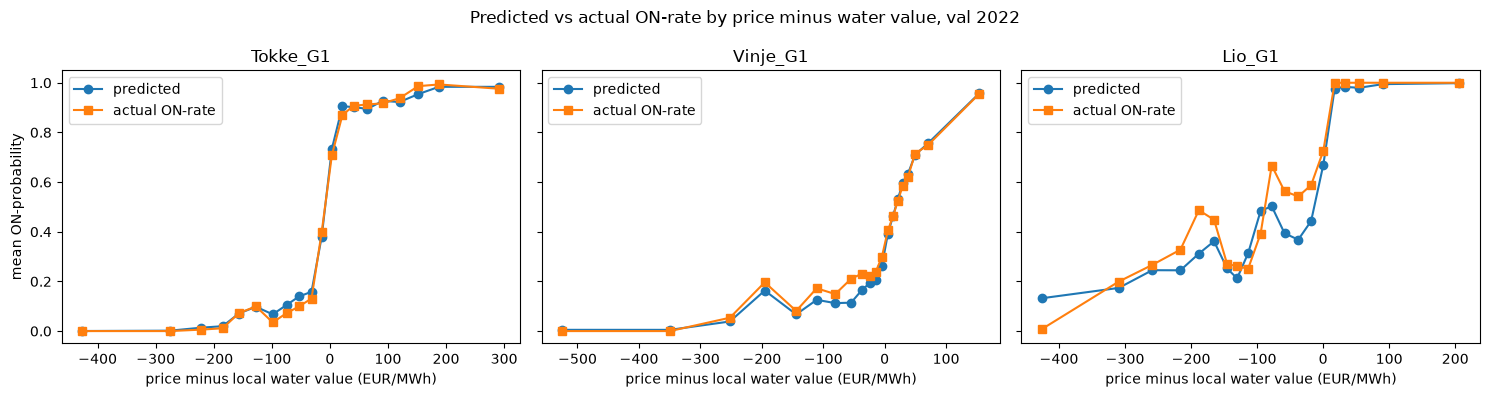

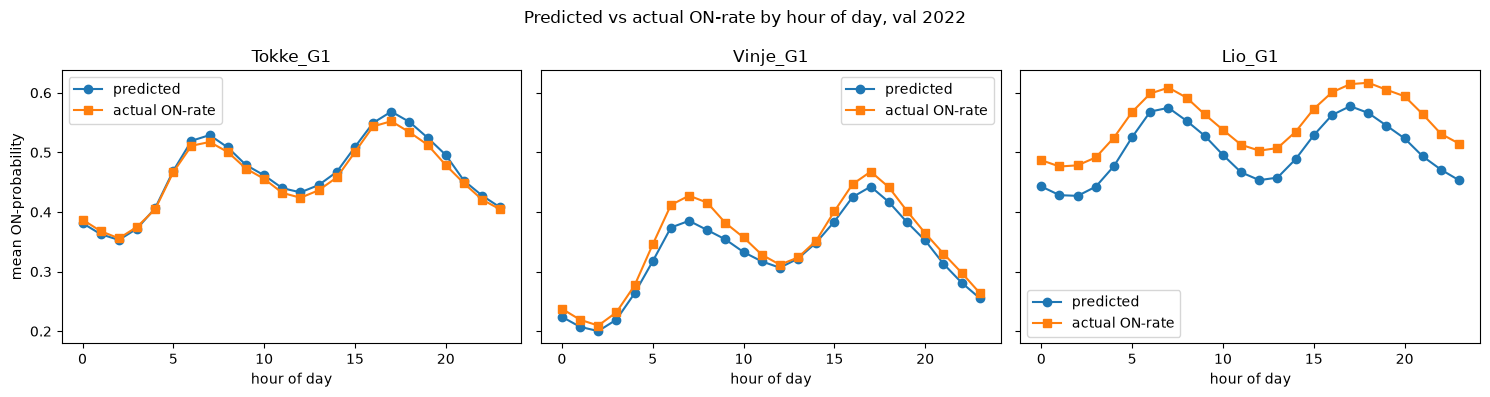

In [7]:
GENS_SHOW = ["Tokke_G1", "Vinje_G1", "Lio_G1"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, gen in zip(axes, GENS_SHOW):
    Xva = generator_features(Xva_base, gen)
    q = pd.DataFrame({
        "x": Xva["local_price_minus_val"].to_numpy(),
        "p": preds[gen],
        "y": labels_for(val_cases, gen),
    })
    q["bin"] = pd.qcut(q["x"], 20, duplicates="drop")
    g = q.groupby("bin", observed=True).agg(xm=("x", "mean"),
                                            p=("p", "mean"), y=("y", "mean"))
    ax.plot(g["xm"], g["p"], marker="o", label="predicted")
    ax.plot(g["xm"], g["y"], marker="s", label="actual ON-rate")
    ax.set_xlabel("price minus local water value (EUR/MWh)")
    ax.set_title(gen)
    ax.legend()
axes[0].set_ylabel("mean ON-probability")
fig.suptitle("Predicted vs actual ON-rate by price minus water value, val 2022")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, gen in zip(axes, GENS_SHOW):
    q = pd.DataFrame({
        "hod": Xva_base["hour_of_day"].to_numpy(),
        "p": preds[gen],
        "y": labels_for(val_cases, gen),
    })
    g = q.groupby("hod").mean()
    ax.plot(g.index, g["p"], marker="o", label="predicted")
    ax.plot(g.index, g["y"], marker="s", label="actual ON-rate")
    ax.set_xlabel("hour of day")
    ax.set_title(gen)
    ax.legend()
axes[0].set_ylabel("mean ON-probability")
fig.suptitle("Predicted vs actual ON-rate by hour of day, val 2022")
fig.tight_layout()
plt.show()